In [1]:
from random import sample

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('dirty_cafe_sales.csv')
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [3]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
df['Location'].unique()

array(['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR'], dtype=object)

In [6]:
df = df.replace(["UNKNOWN","ERROR"], np.nan)

In [7]:
df_1=['Quantity','Price Per Unit','Total Spent']

In [8]:
for i in df_1:
    df[i]=pd.to_numeric(df[i],errors='coerce')
    df[i]=df[i].fillna(df[i].mean().astype('int32'))

In [9]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [10]:
df['Transaction Date']=pd.to_datetime(df['Transaction Date'],errors='coerce')

In [11]:
df_2=['Item','Payment Method','Location','Transaction Date']

In [12]:
for i in df_2:
    df[i]=df[i].fillna(df[i].mode()[0])

In [13]:
df.to_csv('dirty.csv',index=False)

In [14]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30
9996,TXN_9659401,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [15]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [16]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [17]:
df['ChuT ID']=df['Transaction ID']

In [18]:
df=df.drop(columns=['Transaction Date','Transaction ID','ChuT ID'],axis=1)

In [19]:
df

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9995,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway
9996,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway


In [20]:
df.to_csv('Cafe.csv')

In [21]:
df

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9995,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway
9996,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway


<Figure size 3000x100 with 0 Axes>

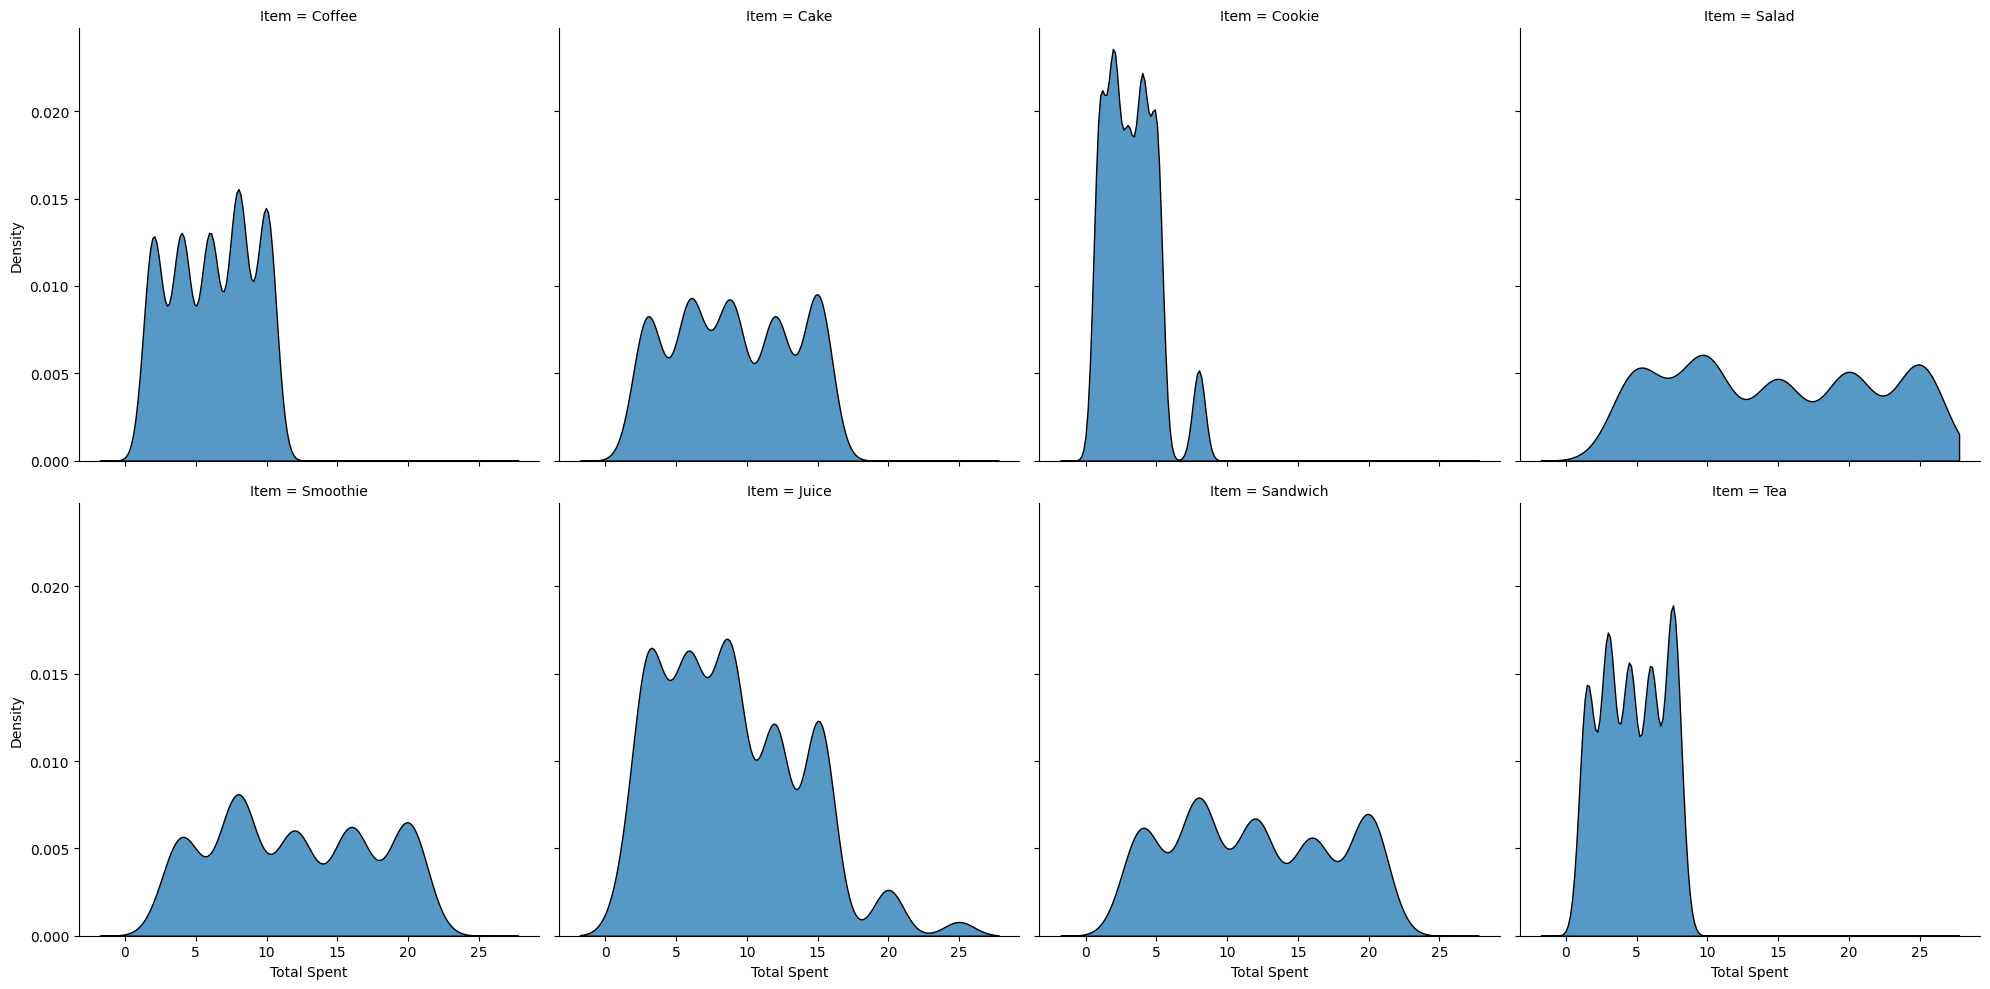

In [22]:
plt.figure(figsize=(30,1))
sns.displot(data=df,x='Total Spent',col='Item',multiple='stack',col_wrap=4,kind='kde')

<Figure size 3000x100 with 0 Axes>

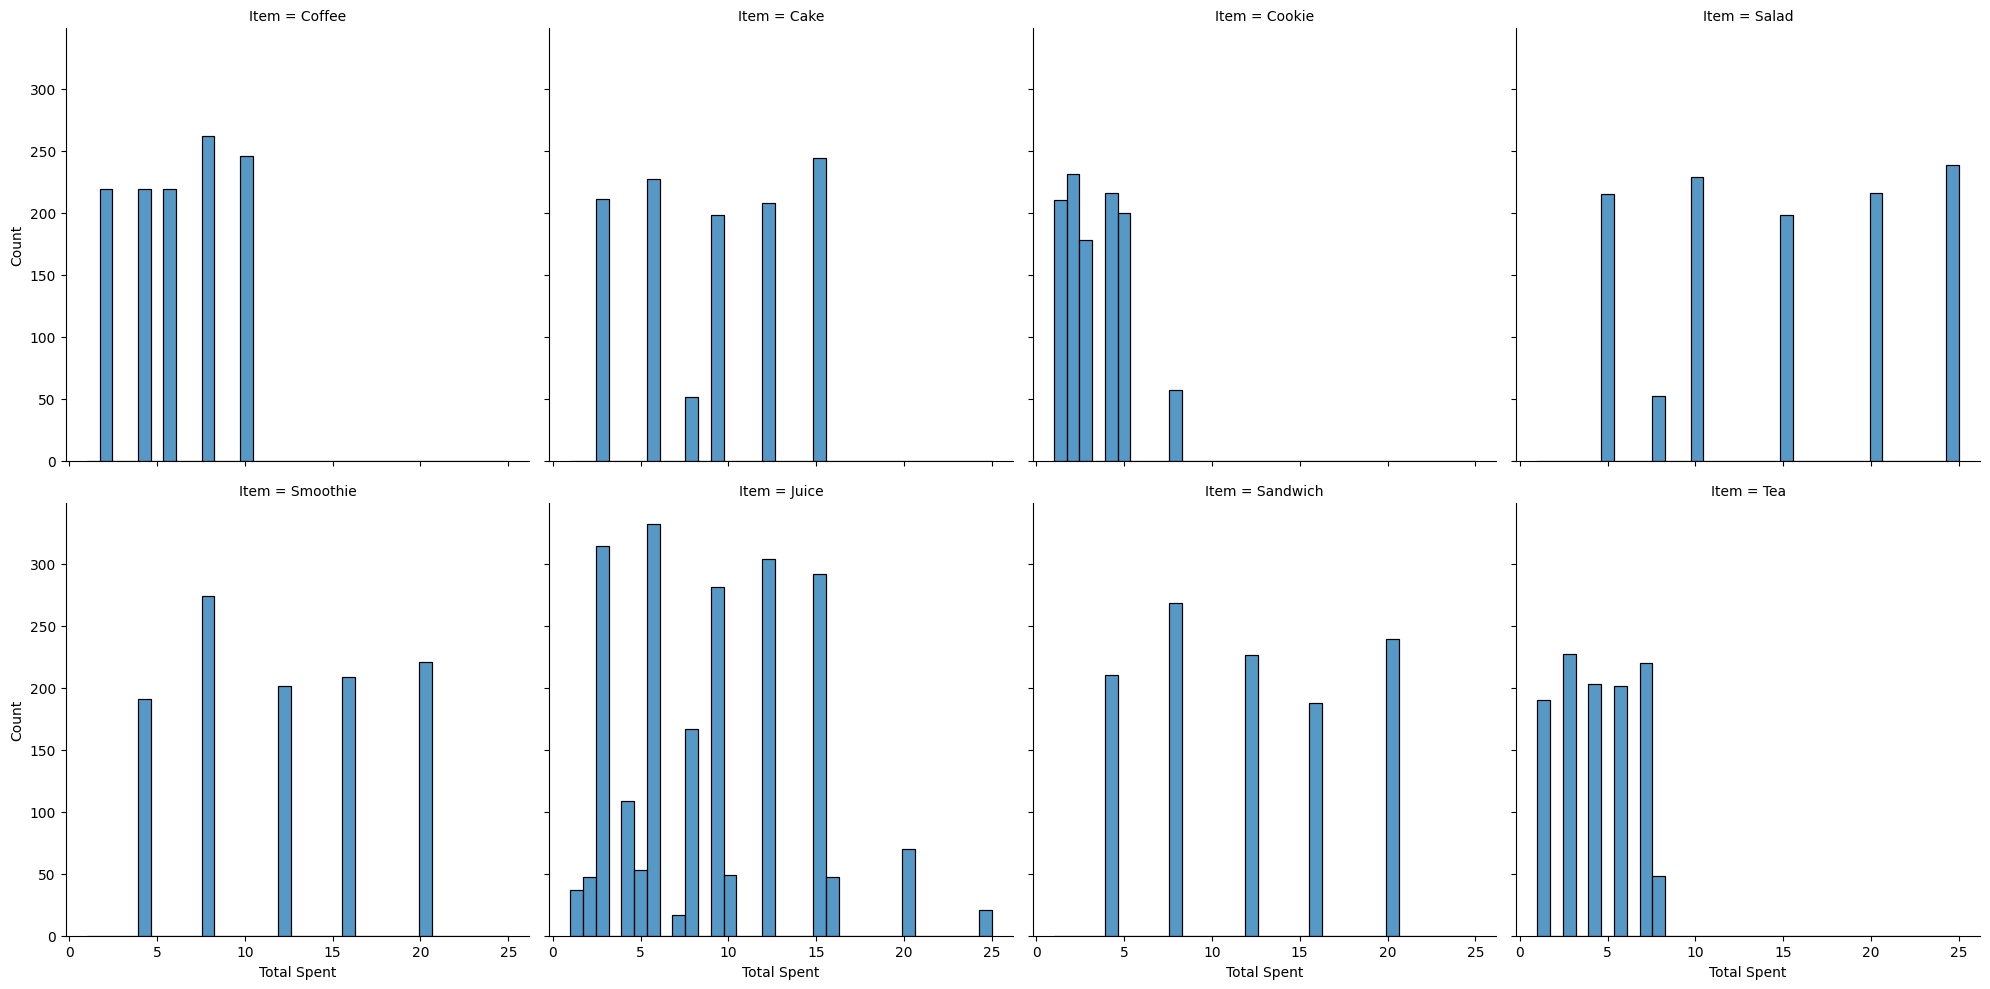

In [23]:
plt.figure(figsize=(30,1))
sns.displot(data=df,x='Total Spent',col='Item',multiple='stack',col_wrap=4)

In [24]:
df

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9995,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway
9996,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway


<Axes: xlabel='Item'>

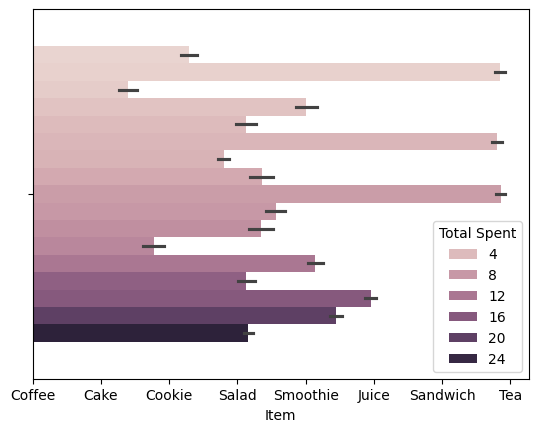

In [25]:
sns.barplot(x='Item',hue='Total Spent',data=df)

<Axes: xlabel='Item', ylabel='Total Spent'>

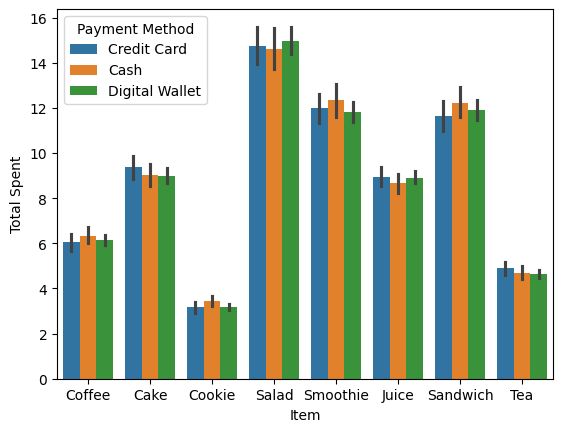

In [26]:
sns.barplot(x='Item',y='Total Spent',hue='Payment Method',data=df)

<Axes: xlabel='Item', ylabel='Total Spent'>

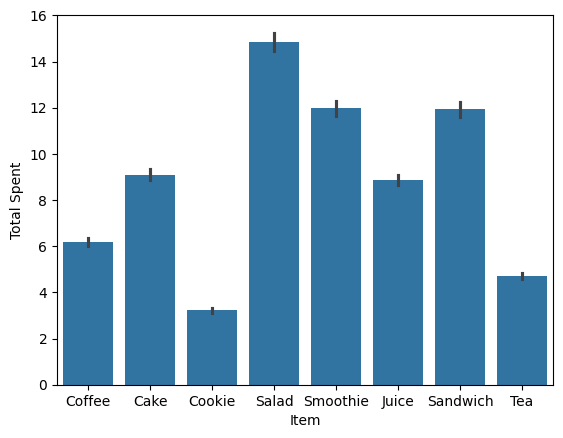

In [27]:
sns.barplot(x='Item',y='Total Spent',data=df)

In [28]:
df

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9995,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway
9996,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway


<Axes: xlabel='Total Spent', ylabel='Item'>

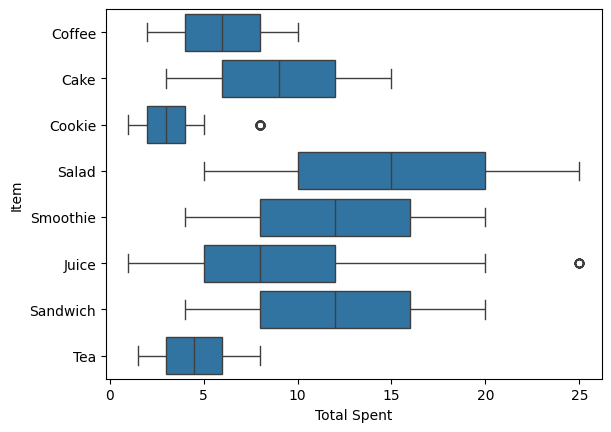

In [29]:
sns.boxplot(data=df,x='Total Spent',y='Item')

<Axes: xlabel='Item', ylabel='Total Spent'>

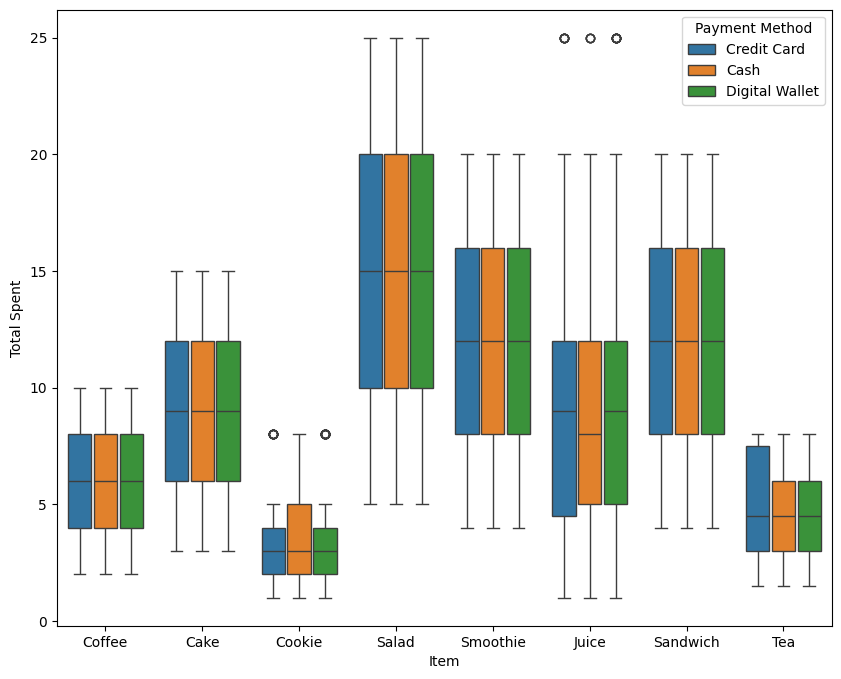

In [30]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='Total Spent',x='Item',hue='Payment Method',gap=.1)

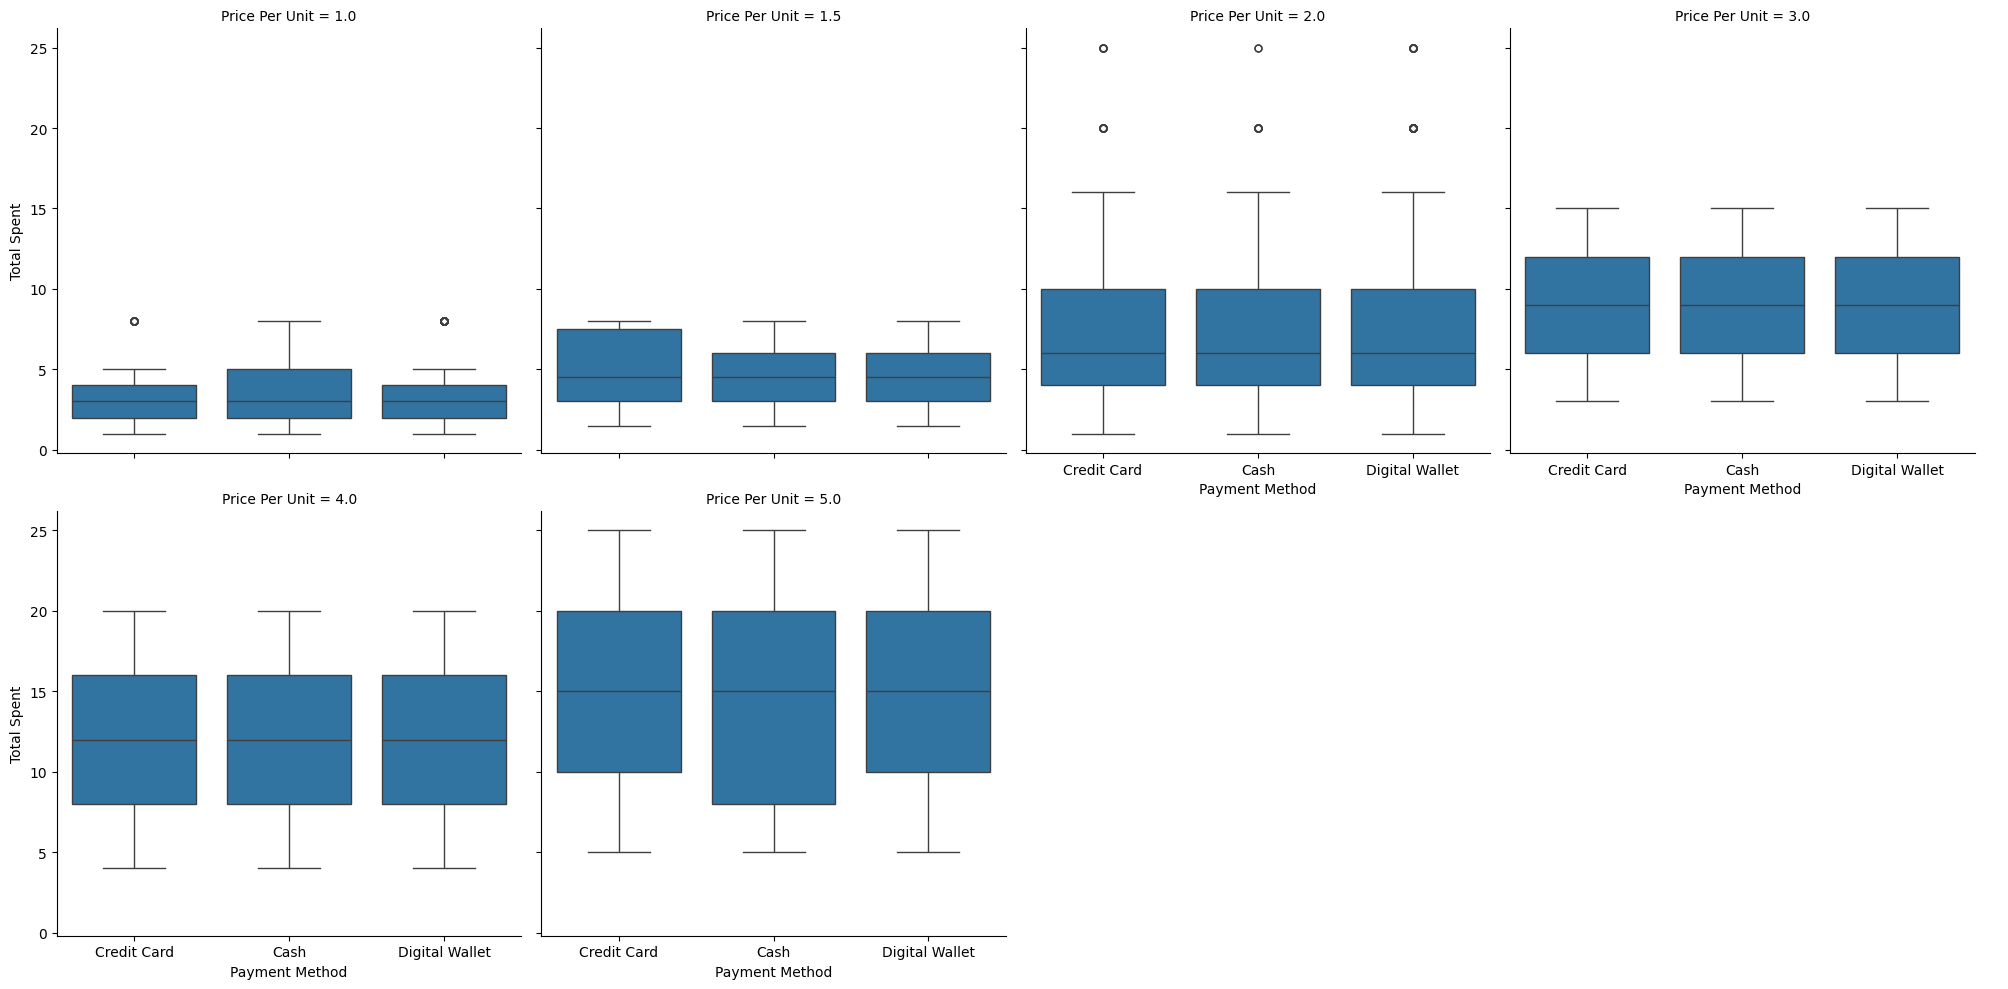

In [31]:
sns.catplot(data=df,x='Payment Method',y='Total Spent',col='Price Per Unit',kind='box',col_wrap=4)

<Axes: xlabel='Item', ylabel='count'>

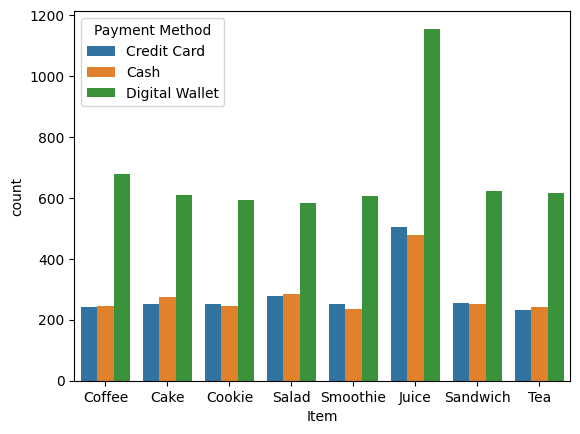

In [32]:
# countpot->item, payment
sns.countplot(data=df,x='Item',hue='Payment Method',)

<Axes: xlabel='Quantity', ylabel='count'>

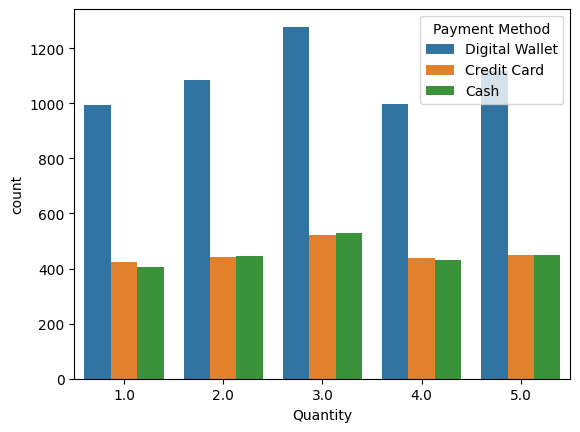

In [33]:
sns.countplot(data=df,x='Quantity',hue='Payment Method',)

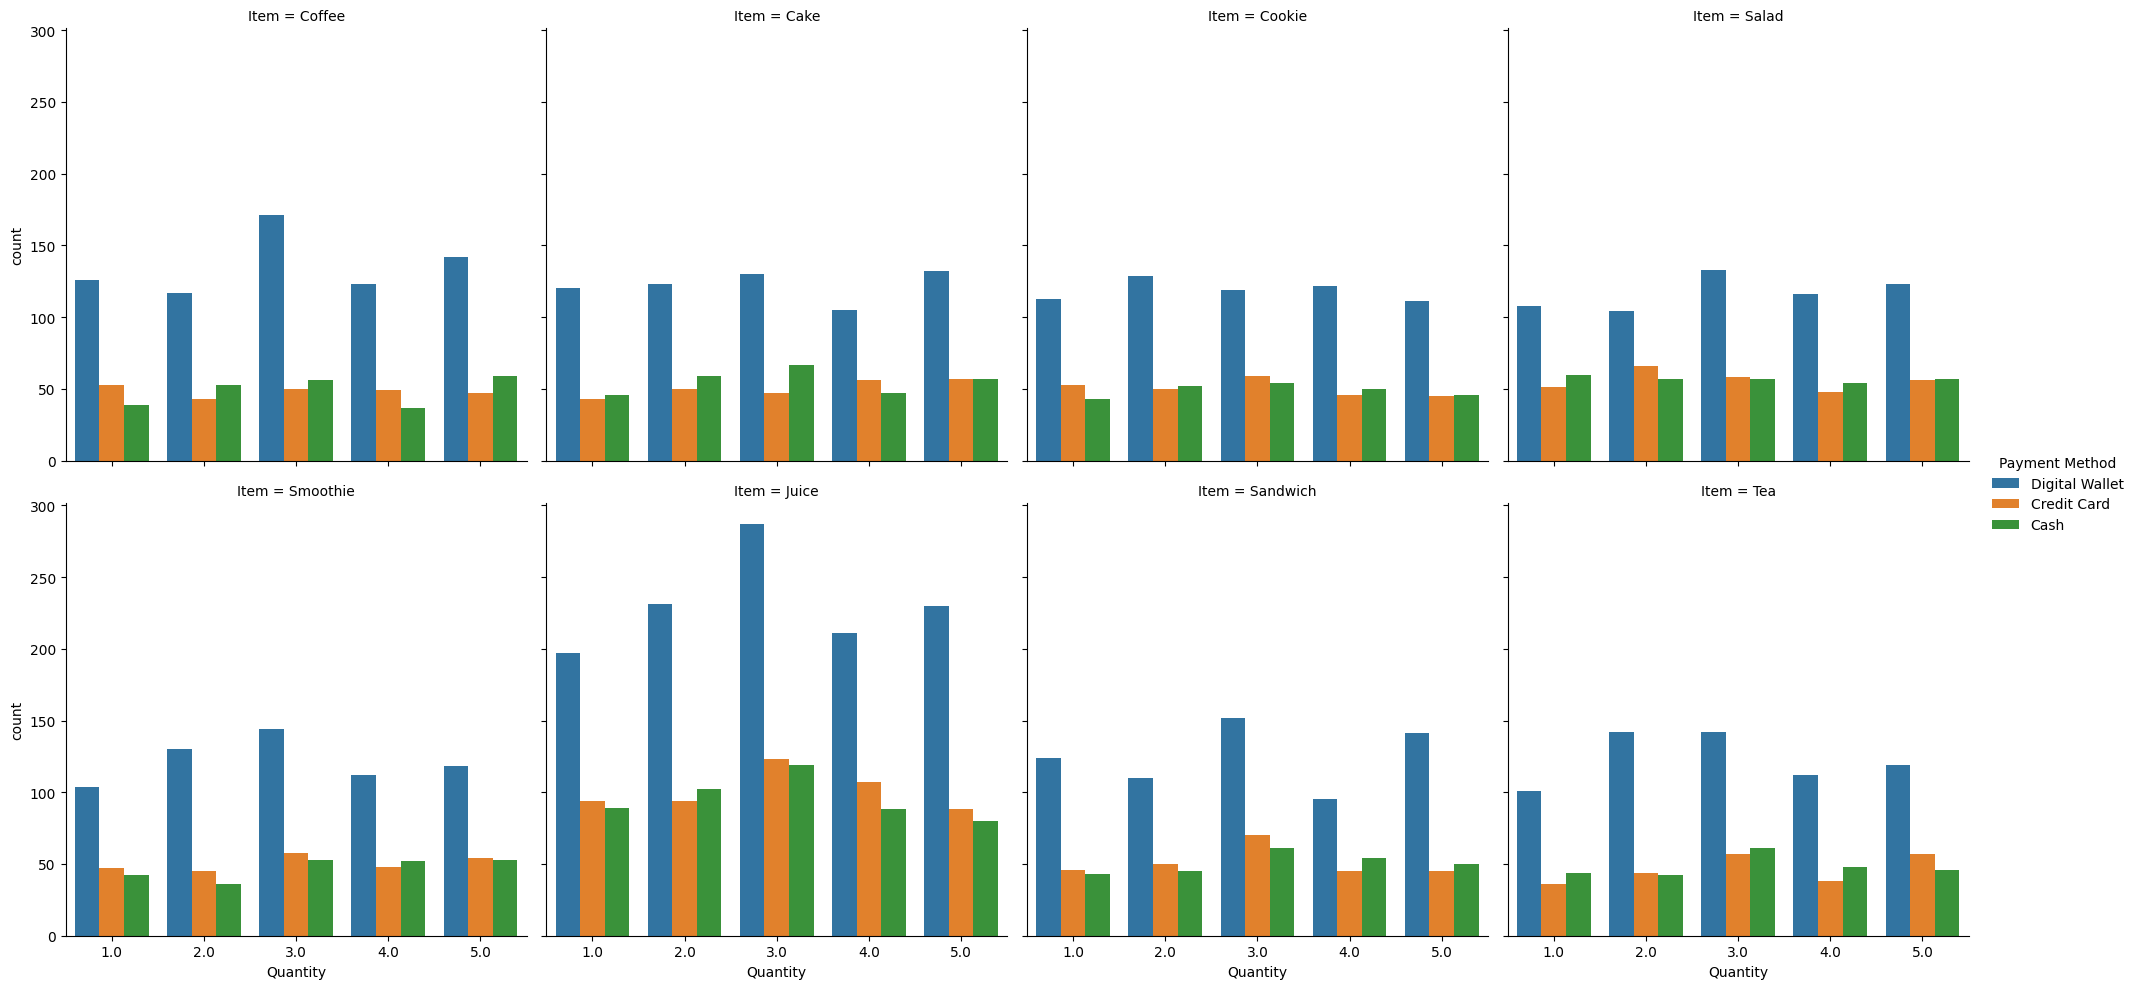

In [34]:
sns.catplot(data=df,x='Quantity',hue='Payment Method',kind='count',col='Item',col_wrap=4)

<Axes: xlabel='Quantity', ylabel='count'>

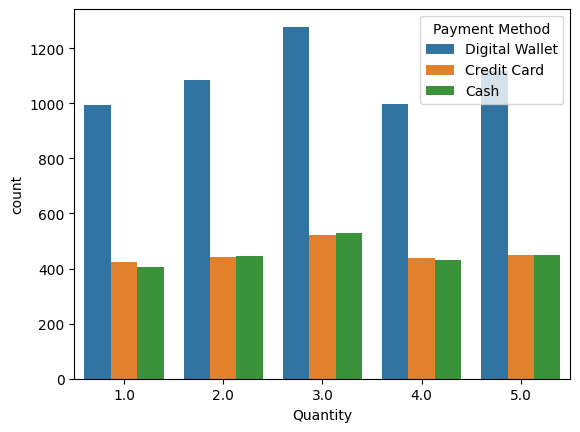

In [35]:
sns.countplot(data=df,x='Quantity',hue='Payment Method',)

<Axes: xlabel='Total Spent', ylabel='count'>

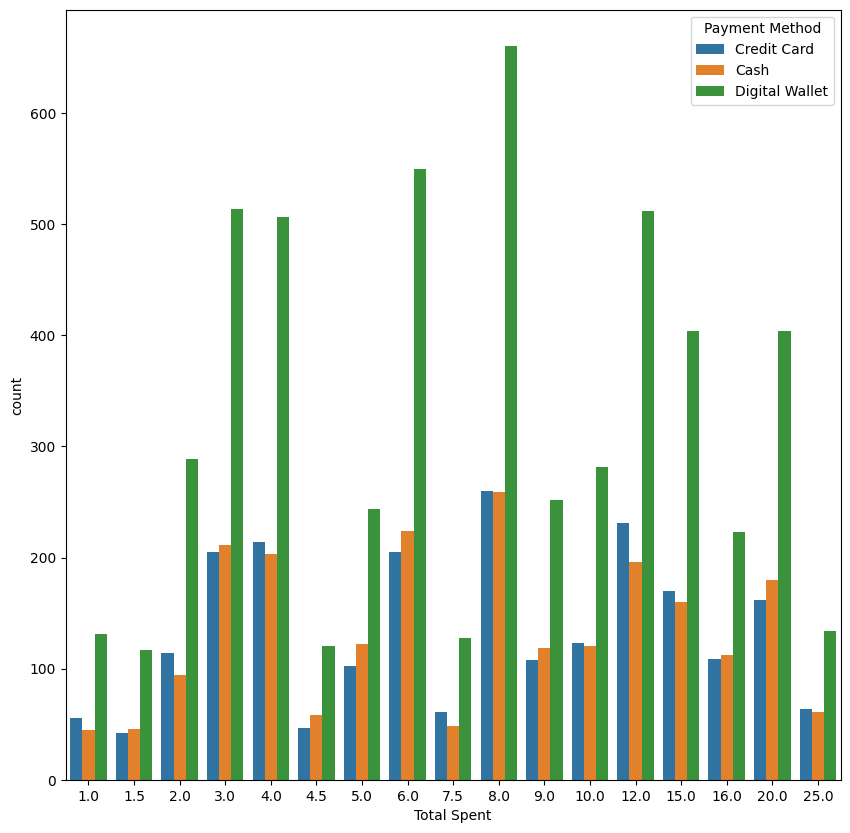

In [36]:
plt.figure(figsize=(10,10))
sns.countplot(data=df,x='Total Spent',hue='Payment Method',)

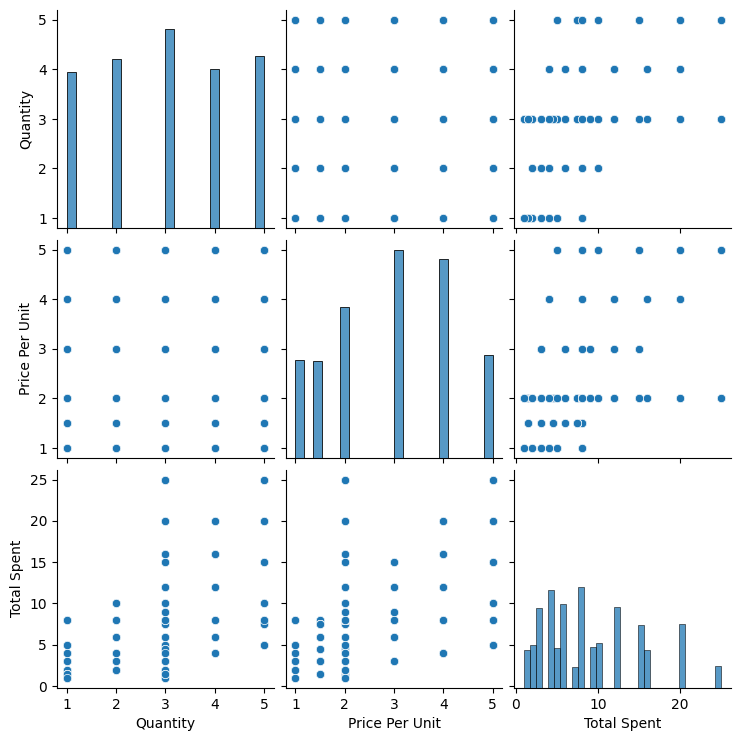

In [37]:
sns.pairplot(data=df)

In [38]:
item_sales = df.groupby("Item")["Total Spent"].sum()
item_sales

Item
Cake        10341.0
Coffee       7184.0
Cookie       3526.0
Juice       18972.0
Salad       17021.0
Sandwich    13484.0
Smoothie    13132.0
Tea          5119.5
Name: Total Spent, dtype: float64

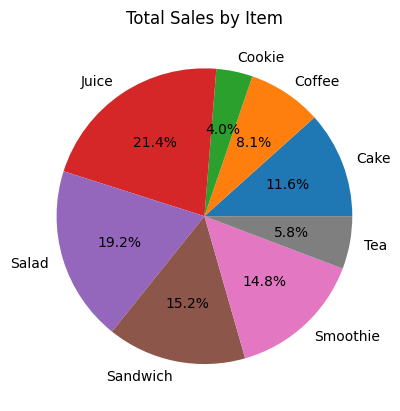

In [39]:
item_sales = df.groupby("Item")["Total Spent"].sum()
plt.figure()
plt.pie(item_sales, labels=item_sales.index, autopct="%1.1f%%")
plt.title("Total Sales by Item")
plt.show()

In [40]:
item_sales = df.groupby("Payment Method")["Total Spent"].sum()
item_sales

Payment Method
Cash              20334.0
Credit Card       20415.0
Digital Wallet    48030.5
Name: Total Spent, dtype: float64

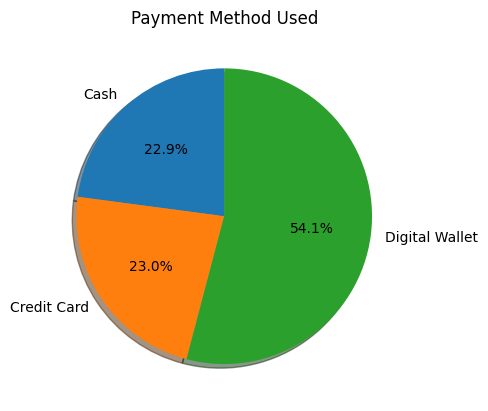

In [41]:
plt.figure()
plt.pie(item_sales, labels=item_sales.index, autopct="%1.1f%%",shadow=True,startangle=90,)
plt.title("Payment Method Used")
plt.show()


In [42]:
df.head(2)

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store


In [43]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'Digital Wallet'], dtype=object)

In [44]:
df.describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.000000,10000.00000
mean,3.027100,2.899350,8.87795
std,1.384614,1.262083,5.86059
min,1.000000,1.000000,1.00000
25%,2.000000,2.000000,4.00000
50%,3.000000,3.000000,8.00000
75%,4.000000,4.000000,12.00000
max,5.000000,5.000000,25.00000


<Axes: xlabel='Quantity', ylabel='Price Per Unit'>

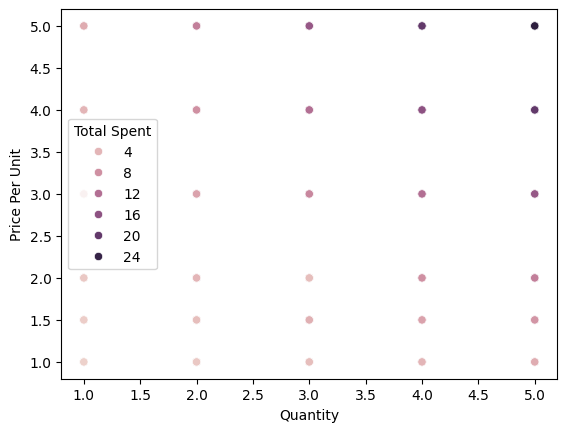

In [45]:
sns.scatterplot(data=df,x='Quantity',y='Price Per Unit',hue='Total Spent')

In [46]:
x=df.drop('Total Spent',axis=1)
y=df['Total Spent']

0        4.0
1       12.0
2        8.0
3       10.0
4        4.0
        ... 
9995     4.0
9996     3.0
9997     8.0
9998     3.0
9999    12.0
Name: Total Spent, Length: 10000, dtype: float64

In [47]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['Item']=le.fit_transform(x['Item'])
x['Payment Method']=le.fit_transform(x['Payment Method'])
x['Location']=le.fit_transform(x['Location'])

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [50]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
lr.score(x_test,y_test)*100

80.18986713893915

In [61]:
lr.predict(x)

array([ 3.38895944, 11.89121399,  6.38911136, ...,  9.05534425,
        6.23399156, 11.95242201])

<Axes: ylabel='Count'>

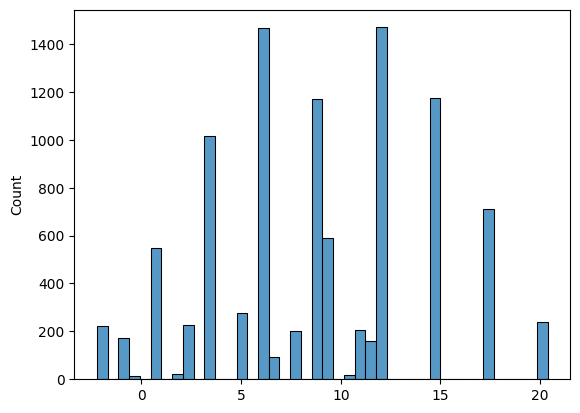

In [68]:
# sns.histplot(x)
sns.histplot(lr.predict(x))

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = lr.predict(x_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


MAE: 1.7941842633835163
MSE: 6.7902090964471205


<Axes: xlabel='Total Spent'>

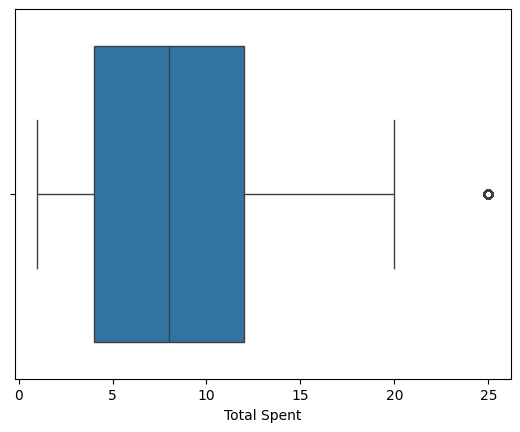

In [54]:
sns.boxplot(data=df,x='Total Spent')

In [55]:
df

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9995,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway
9996,Juice,3.0,2.0,3.0,Digital Wallet,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,2.0,3.0,Digital Wallet,Takeaway


In [70]:
y,x1

(0        4.0
 1       12.0
 2        8.0
 3       10.0
 4        4.0
         ... 
 9995     4.0
 9996     3.0
 9997     8.0
 9998     3.0
 9999    12.0
 Name: Total Spent, Length: 10000, dtype: float64,
 array([ 3.38895944, 11.89121399,  6.38911136, ...,  9.05534425,
         6.23399156, 11.95242201]))

<BarContainer object of 10000 artists>

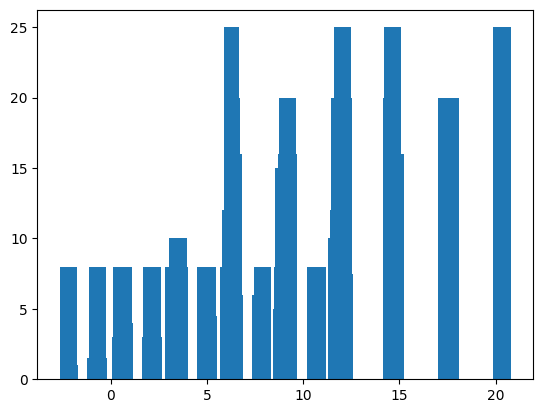

In [82]:
plt.bar(x1,y)



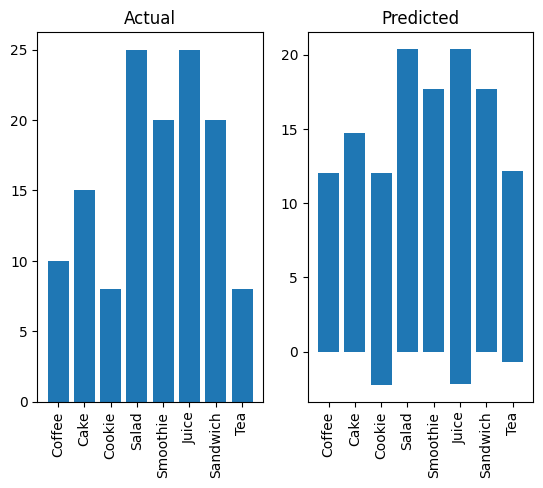

In [101]:
plt.subplot(1,2,1)
plt.bar(df['Item'],y)
plt.xticks(rotation=90)
plt.title('Actual')
# plt.bar(df['Item'],x1)
plt.subplot(1,2,2)
plt.bar(df['Item'],x1)
plt.xticks(rotation=90)
plt.title('Predicted')
plt.show()

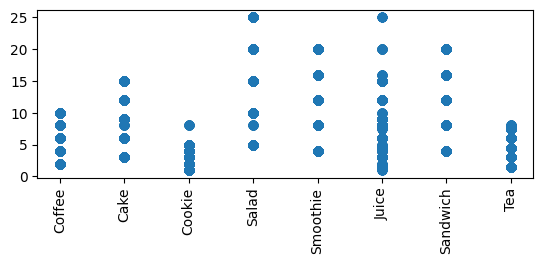

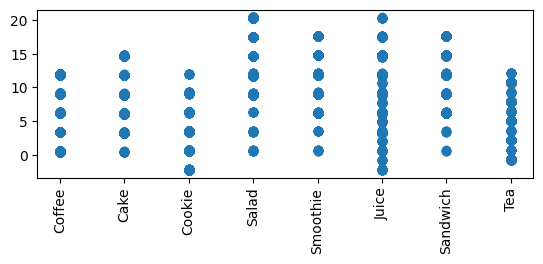

In [96]:
plt.subplot(2,1,1)
plt.scatter(df['Item'],y)
plt.xticks(rotation=90)
plt.show()
# plt.bar(df['Item'],x1)
plt.subplot(2,1,2)
plt.scatter(df['Item'],x1)
plt.xticks(rotation=90)
plt.show()

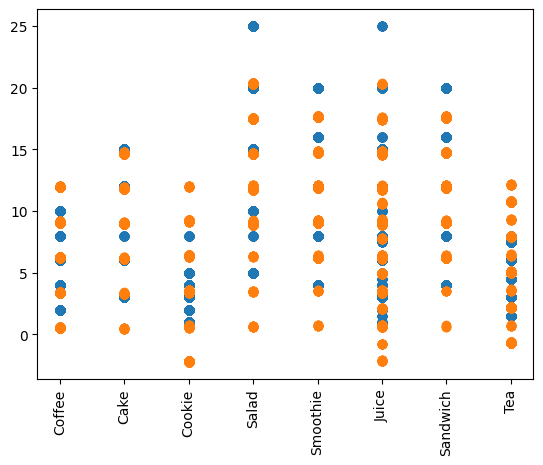

In [99]:
plt.scatter(df['Item'],y)
plt.xticks(rotation=90)
plt.scatter(df['Item'],x1)
plt.xticks(rotation=90)
plt.show()